## 02 探索性資料分析

本章節針對 12,106 筆有效高中生樣本進行初步檢視。透過探討自變數「每日睡眠時數」與應變數「悲傷與絕望感」之交叉分佈，旨在觀察數據之核心趨勢與機率分佈，並為後續進行之「Logistic Regression 分析模型」奠定預測機率之論證基礎。

### 各睡眠組別之悲傷比例長條圖觀察 

* **分佈落差與趨勢**：
   長條圖顯示，不同睡眠時數組別的高中生，其感到悲傷或絕望的比例存在明顯差異。整體呈現**負向趨勢**：在極短睡眠組別（代號 1）中，悲傷比例最高（**0.51**）；而隨著睡眠時 間增加，在中等理想睡眠組別（代號 5）中則穩定下降至區間最低點（**0.22**）。
* **非線性轉折特徵**：
  數據在較高睡眠組別（代號 6 與 7）中出現些微波動與回升，提示睡眠不足與極端高睡眠群體在心理健康層面上可能具備相異之潛在特徵。
* **顯著性預測鋪墊**：
  各組別間肉眼可見的比例落差，初步支持了睡眠時數與悲傷機率的關聯性，直接為後續 **Logistic Regression** 模型之預測效果與統計顯著性奠定論證基礎。

## 02 Exploratory Data Analysis

This section conducts a preliminary examination of the 12,106 valid high school student samples. By exploring the cross-distribution between the independent variable "Daily Hours of Sleep" and the dependent variable "Feelings of Sadness and Hopelessness," we aim to observe the core trends and probability distributions within the data, establishing a solid foundational baseline for the subsequent Logistic Regression Model.

###  Bar Chart Observation of Sadness Proportions Across Sleep Groups

* **Distribution Gaps and Trends**:
  The bar chart indicates distinct variations in the proportion of high school students experiencing sadness or hopelessness across different sleep duration groups. Overall, the data exhibits a **negative trend**: the highest proportion of sadness is observed in the shortest sleep group (Code 1) at **0.51**, whereas it steadily declines to the interval's lowest point of **0.22** in the mid-range ideal sleep group (Code 5).
* **Non-linear Turning Point Characteristics**:
  The data shows minor fluctuations and a slight rebound in the higher sleep groups (Codes 6 and 7), suggesting that short-sleep groups and extreme long-sleep groups might possess distinct underlying characteristics regarding mental health.
* **Significance Prediction Baseline**:
  The visually prominent gaps in proportions across groups preliminarily support the association between sleep duration and the likelihood of sadness, directly setting the stage for the rigorous verification of predictive performance and statistical significance in the upcoming **Logistic Regression** model.

🎉 成功把資料抓過來了！有效分析樣本數：12106 筆

--- 📊 各睡眠組別悲傷比例統計 (Grouped Statistics) ---
 Sleep  Sad_Recoded
   1.0     0.513263
   2.0     0.410484
   3.0     0.323928
   4.0     0.253459
   5.0     0.224901
   6.0     0.255405
   7.0     0.284000
--------------------------------------------------

💾 【第二步完全成功】趨勢長條圖已儲存至 'outputs/sleep_vs_sadness_plot.png'！


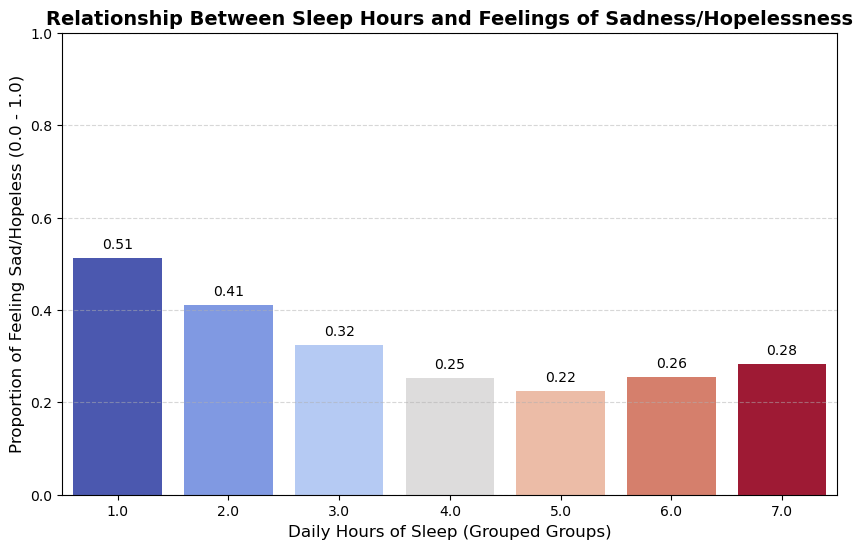

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 【核心關鍵】把前一步清理好的資料抓過來！
# ==========================================
try:
    cleaned_df = pd.read_csv('data/cleaned_data.csv')
except FileNotFoundError:
    # 如果你的 02 檔案是在 notebooks 資料夾內，嘗試往上一層找 data
    cleaned_df = pd.read_csv('../data/cleaned_data.csv')

print(f"🎉 成功把資料抓過來了！有效分析樣本數：{len(cleaned_df)} 筆")

# ==========================================
# 2. 依據睡眠時數分組，計算悲傷比例的平均值
# ==========================================
grouped_data = cleaned_df.groupby('Sleep')['Sad_Recoded'].mean().reset_index()

print("\n--- 📊 各睡眠組別悲傷比例統計 (Grouped Statistics) ---")
print(grouped_data.to_string(index=False))
print("--------------------------------------------------\n")

# ==========================================
# 3. 繪製專業趨勢長條圖
# ==========================================
plt.figure(figsize=(10, 6))
sns.barplot(x='Sleep', y='Sad_Recoded', data=grouped_data, palette='coolwarm', hue='Sleep', legend=False)

plt.title('Relationship Between Sleep Hours and Feelings of Sadness/Hopelessness', fontsize=14, fontweight='bold')
plt.xlabel('Daily Hours of Sleep (Grouped Groups)', fontsize=12)
plt.ylabel('Proportion of Feeling Sad/Hopeless (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 在長條圖上方精準標示比例數字
for index, row in grouped_data.iterrows():
    plt.text(index, row['Sad_Recoded'] + 0.02, f"{row['Sad_Recoded']:.2f}", color='black', ha="center", fontsize=10)

# ==========================================
# 4. 儲存圖片
# ==========================================
if not os.path.exists('outputs'):
    os.makedirs('outputs')
plt.savefig('outputs/sleep_vs_sadness_plot.png', dpi=300, bbox_inches='tight')

print("💾 【第二步完全成功】趨勢長條圖已儲存至 'outputs/sleep_vs_sadness_plot.png'！")
plt.show()

### 各睡眠組別之悲傷比例長條圖觀察

不同睡眠時數組別之高中生，其感到悲傷或絕望的比例存在明顯差異。整體而言，隨著睡眠時間增加，悲傷比例呈現下降趨勢。在最短睡眠組別中，悲傷比例最高，約為 0.51；而在中等睡眠組別中則下降至約 0.22。雖然在較高睡眠組別中出現些微波動，但整體趨勢仍顯示睡眠時間較短之學生具有較高的悲傷比例。

### Bar Chart Observation of Sadness Proportions Across Sleep Groups

There are distinct variations in the proportion of high school students experiencing sadness or hopelessness across different sleep duration groups. Overall, as sleep duration increases, the proportion of sadness exhibits a downward trend. The highest proportion of sadness is observed in the shortest sleep group, at approximately 0.51, whereas it declines to around 0.22 in the mid-range sleep group. Although minor fluctuations appear in the higher sleep groups, the overall trend consistently indicates that students with shorter sleep durations exhibit a higher prevalence of sadness.